# Configuracion Inicial

### Importar Librerias

In [29]:
import os
import pandas as pd                     # PARA MANIPULACION DE ARCHIVOS
import pyodbc                           # PARA CONEXION CON BASE DE DATOS
import numpy as np                      # PARA CALCULOS MATEMATICOS
import seaborn as sns                   # PARA GRAFICAS ATRACTIVAS E INFORMATIVAS
import matplotlib.pyplot as plt         # PARA GRAFICOS

### Carga de Variables de Entorno

### Conexion con base de datos

# 1. Preparación de datos: 

### a. Extraer los datos del archivo .csv.

In [30]:
df = pd.read_csv("winequality-red.csv", sep=";")
df.head()  # Mostrar primeras filas

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### b. Verificar si hay valores nulos o duplicados y decidir cómo manejarlos.

In [31]:
print("Valores nulos por columna:\n", df.isnull().sum())

#eliminamos duplicados
df = df.drop_duplicates()

Valores nulos por columna:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### c. Resumen estadístico de los datos

In [32]:
resumen = df.describe(include="all")
print(resumen)

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1359.000000       1359.000000  1359.000000     1359.000000   
mean        8.310596          0.529478     0.272333        2.523400   
std         1.736990          0.183031     0.195537        1.352314   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.430000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1359.000000          1359.000000           1359.000000  1359.000000   
mean      0.088124            15.893304             46.825975     0.996709   
std       0.049377            10.447270             33.408946     0.001869   
min       0.012000             1.000000         

### d. Matriz de correlación

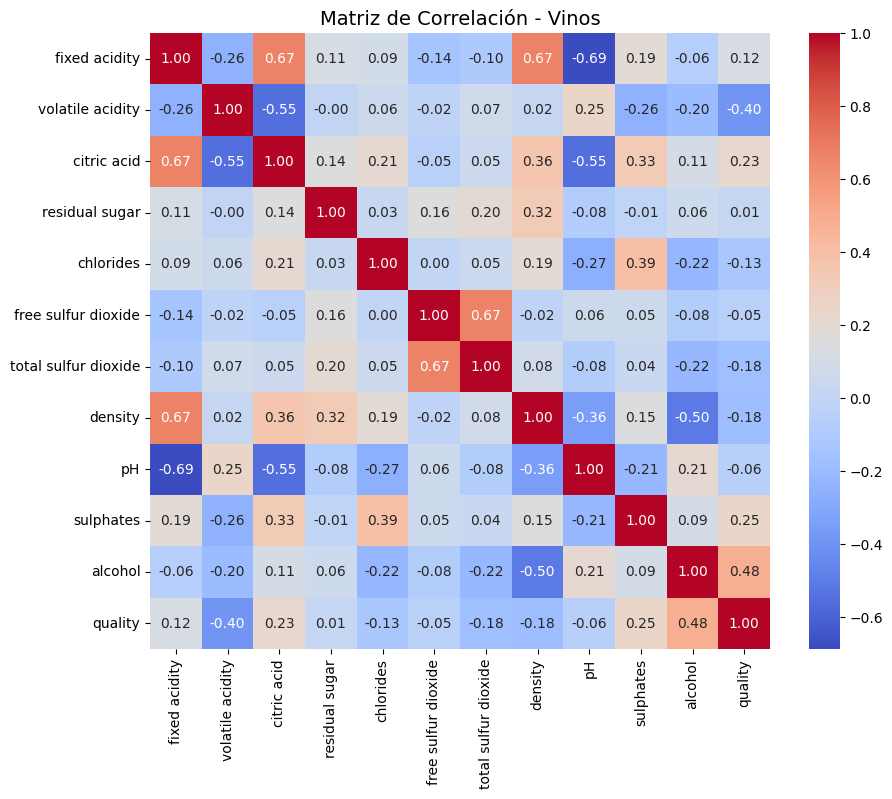

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Matriz de Correlación - Vinos", fontsize=14)
plt.show()

# 2. Graficos

### a. Calidad del vino

C:\Users\cutza\AppData\Local\Temp\ipykernel_9096\1672847973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="quality", data=df, palette="Set2")


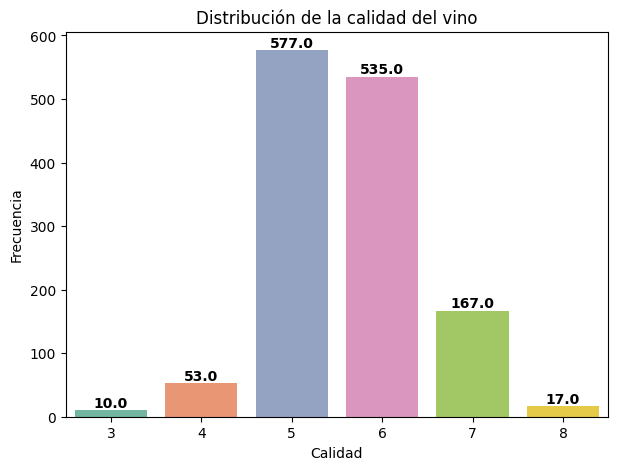

In [21]:
# Histograma de la calidad con etiquetas en cada barra
plt.figure(figsize=(7,5))
ax = sns.countplot(x="quality", data=df, palette="Set2")

# Títulos y ejes
plt.title("Distribución de la calidad del vino")
plt.xlabel("Calidad")
plt.ylabel("Frecuencia")

# Agregar etiquetas arriba de cada barra
for p in ax.patches:
    ax.annotate(
        str(p.get_height()),                  # valor de la barra
        (p.get_x() + p.get_width() / 2., p.get_height()),  # posición
        ha='center', va='bottom', fontsize=10, color="black", fontweight="bold"
    )

plt.show()


### b. Dispersión: alcohol vs calidad

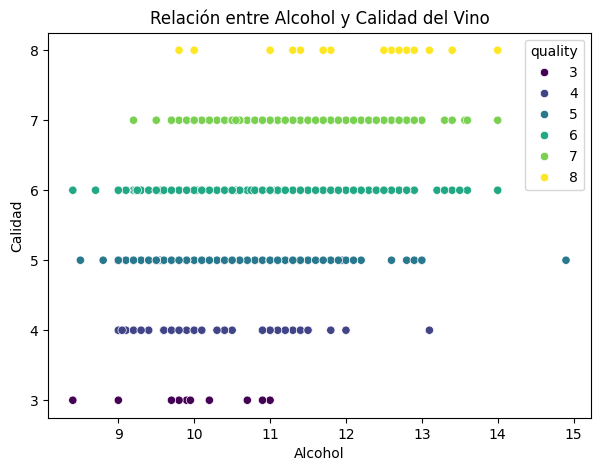

In [27]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="alcohol", y="quality", data=df, hue="quality", palette="viridis")
plt.title("Relación entre Alcohol y Calidad del Vino")
plt.xlabel("Alcohol")
plt.ylabel("Calidad")
plt.show()

### c. Distribución de ácido cítrico

C:\Users\cutza\AppData\Local\Temp\ipykernel_9096\3465510366.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["citric acid"], shade=True, color="green")


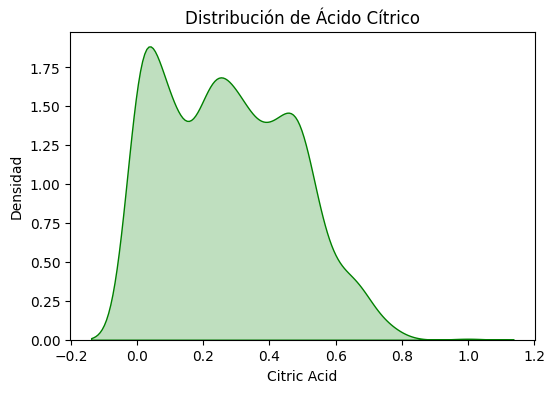

In [28]:
plt.figure(figsize=(6,4))
sns.kdeplot(df["citric acid"], shade=True, color="green")
plt.title("Distribución de Ácido Cítrico")
plt.xlabel("Citric Acid")
plt.ylabel("Densidad")
plt.show()


# Conclusiones

+ La mayoria de los vinos tienen una calidad entre 5-6 y muy pocos con una calidad baja. La empresa puede enfocarse en mejorar las características de los vinos promedio para aumentar la cantidad de vinos de calidad alta. 

+ El nivel de alcohol del vino influye la percepción de calidad por parte de los consumidores. Los vinos con mayor contenido de alcohol tienden a tener mejores calificaciones, aunque no es una regla estricta.

+ La densidad máxima se concentra en valores bajos, alrededor de 0.0 a 0.2, indicando que la mayoría de los vinos tienen poco ácido cítrico. La empresa puede enfocarse en la mayoría de vinos con bajo ácido cítrico, ya que es el rango más común, pero también puede experimentar con vinos con valores moderados para ofrecer una mayor variedad sin afectar la densidad de vinos estándar.